## Learning the CVA by Neural Net Regression

The CVA at a pricing date $t_i$ is a conditional expectation given the state $\mathcal{X}_{t_i} = (Z_{t_i}, X_{t_i})$ (market risk factors + default indicator) $$ \mathrm{CVA}_{t_i} = \mathbb{E}\big[\xi_i \mid \mathcal{X}_{t_i}\big] =: u_i(\mathcal{X}_{t_i}) $$
where $\xi_i$ is the pathwise discounted default-loss cash flow accumulated over $[t_i, T]$, whose explicit form depends on the indicator/intensity formulation that we've presented in the notebook `1_nested_cva_estimator.ipynb`.

Rather than a NMC, we exploit the $L^2$-projection characterization of the conditional expectation presented in the course $$ u_i(\cdot) = \arg\min_{h \in \mathcal{B}} \, \mathbb{E}\big[(\xi_i - h(\mathcal{X}_{t_i}))^2\big] $$ which reformulates the CVA as a regression problem and approximates $u_i$ by a neural net $h_\theta$ trained to minimize the empirical $L^2$ loss over simulated paths.

We approximate each $u_i = u_i(\mathcal{X}_{t_i})$ by a feedforward neural net $h_{\theta_i}$, a MLP with ReLU activations (given the input dimensionality $d = 2$) and a Kaiming initialization for ReLU layers and zero biases. Training also includes early stopping on a held-out validation split and rollback to the best checkpoint. Moreover, instead of training the networks independently, we exploit sequential/backward training (presented in the course as a form of transfer learning). We go backward in time over the pricing grid, initializing the network at time $t_i$ with the optimized parameters obtained at $t_{i+1}$ [[9]](#gpw). The NN framework is implemented in `nn_regressor.py`.

In [1]:
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from simulation.simulation import (
    simulate_outer_market_paths,
    compute_fixing_window_size,
    simulate_nested_cva,
)
from products.irs.gpu import calibrate_swap_rate_at_par
from cva_nn_estimator import compute_cva_labels, LearnedCVA
from nn_regressor import Regressor
from utils import train_with_oos_tracking, simulate_and_label

In [2]:
# keeping same params and setup as NMC for direct comparison
# time discretization grid
dT = 0.1
num_substeps = 5
dt = dT / num_substeps
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)

# Risk factors parameters 
# Vasicek short rate (a, b, sigma)
# CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0.3
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015

In [3]:
# swaps ptf (same config as Nested Monte carlo IRS Case study)

np.random.seed(0)

num_irs = 100
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # heavy asset
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)

print(f"{num_irs} swaps | p_pay_fixed={prop_pay_fixed} | at_par={at_par} | "
      f"max maturity={max(s['num_resets'] for s in irs)*reset_freq:.1f}y")

100 swaps | p_pay_fixed=0.75 | at_par=False | max maturity=10.0y


In [5]:
num_outer_paths = 4096                
fixing_window_size = compute_fixing_window_size(irs, dt, dT)
rng = np.random.default_rng(42)
X, default_step, rate_integral_path, gamma_integral_path = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho, rng=rng,
)

labels computed in 0.11s
[t=99] training NN
[t=98] training NN
[t=97] training NN
[t=96] training NN
[t=95] training NN
[t=94] training NN
[t=93] training NN
[t=92] training NN
[t=91] training NN
[t=90] training NN
[t=89] training NN
[t=88] training NN
[t=87] training NN
[t=86] training NN
[t=85] training NN
[t=84] training NN
[t=83] training NN
[t=82] training NN
[t=81] training NN
[t=80] training NN
[t=79] training NN
[t=78] training NN
[t=77] training NN
[t=76] training NN
[t=75] training NN
[t=74] training NN
[t=73] training NN
[t=72] training NN
[t=71] training NN
[t=70] training NN
[t=69] training NN
[t=68] training NN
[t=67] training NN
[t=66] training NN
[t=65] training NN
[t=64] training NN
[t=63] training NN
[t=62] training NN
[t=61] training NN
[t=60] training NN
[t=59] training NN
[t=58] training NN
[t=57] training NN
[t=56] training NN
[t=55] training NN
[t=54] training NN
[t=53] training NN
[t=52] training NN
[t=51] training NN
[t=50] training NN
[t=49] training NN
[t=48]

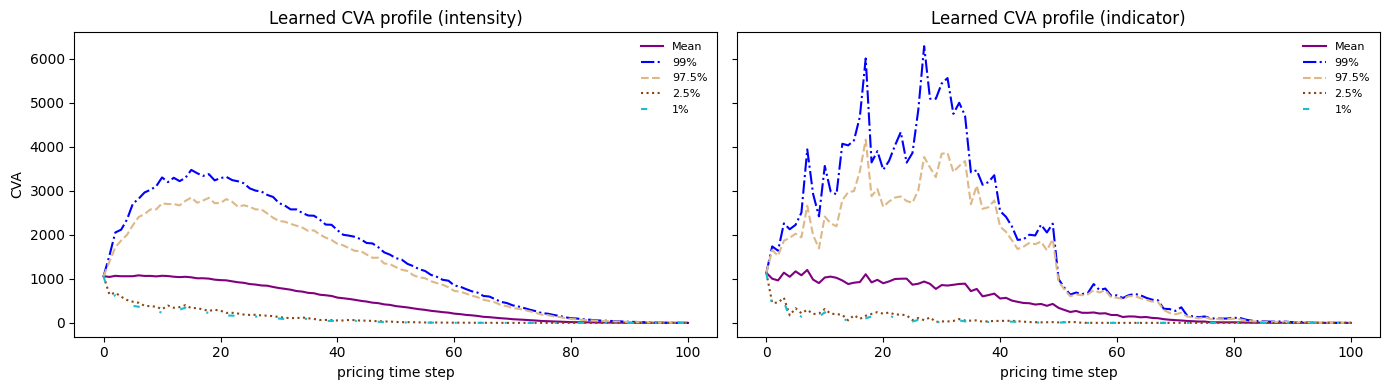

In [10]:
# computing CVA labels
t0 = time.time()
labels_int = compute_cva_labels(
    X, rate_integral_path, gamma_integral_path, default_step,
    irs, diff_params, dt, dT,
    fixing_window_size, num_substeps,
    num_steps_total, num_outer_paths,
    formulation='intensity',
)
labels_ind = compute_cva_labels(
    X, rate_integral_path, gamma_integral_path, default_step,
    irs, diff_params, dt, dT,
    fixing_window_size, num_substeps,
    num_steps_total, num_outer_paths,
    formulation='indicator',
)
print(f"labels computed in {time.time()-t0:.2f}s")

# features_by_t (short rate + gamma)
input_dim = 2
features_by_t = np.zeros((num_steps_total + 1, num_outer_paths, input_dim), dtype=np.float32)
for step in range(num_steps_total + 1):
    idx = (fixing_window_size - 1) if step == 0 else (fixing_window_size + step - 1)
    features_by_t[step, :, 0] = X[idx, 0, :] # r_t
    features_by_t[step, :, 1] = X[idx, 1, :] # gamma_t

# train Cva nn regressor per formulation (ind/def)
def train_and_predict(labels):
    learner = LearnedCVA(
        num_steps_total=num_steps_total, input_dim=input_dim,
        hidden_units=32, num_hidden_layers=2,
        lr=1e-3, num_epochs=100, batch_size=256,
        val_frac=0.1, early_stop=True, patience=15,
        device='cpu', seed=0, verbose=False,
    )
    learner.fit(features_by_t, labels)
    return learner, learner.predict(features_by_t)

learner_int, cva_int = train_and_predict(labels_int)
learner_ind, cva_ind = train_and_predict(labels_ind)

# learned cva profile
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100, sharey=True)
for ax, cva, title in [(axes[0], cva_int, 'intensity'), (axes[1], cva_ind, 'indicator')]:
    ax.plot(cva.mean(axis=1), label='Mean', color='purple')
    ax.plot(np.percentile(cva, 99, axis=1), label='99%', color='blue', linestyle='dashdot')
    ax.plot(np.percentile(cva, 97.5, axis=1), label='97.5%', color='burlywood', linestyle='dashed')
    ax.plot(np.percentile(cva, 2.5, axis=1), label='2.5%', color='saddlebrown', linestyle='dotted')
    ax.plot(np.percentile(cva, 1, axis=1), label='1%', color='tab:cyan', linestyle=(0, (3, 10, 1, 10)))
    ax.set_xlabel('pricing time step')
    ax.set_title(f'Learned CVA profile ({title})')
    ax.legend(loc='upper right', frameon=False, fontsize=8)
axes[0].set_ylabel('CVA')
plt.tight_layout()
plt.show()

To validate the learned model out-of-sample we compare learned CVA to NMC generated values at t = 2y, t = 5y and t = 7y.


 Nested MC estimate at t=1.0y (step 10) ===
  intensity: 4.7s | mean=1079.12
  indicator: 4.6s | mean=1082.07

 Nested MC estimate at t=2.0y (step 20) ===
  intensity: 3.5s | mean=972.76
  indicator: 3.4s | mean=960.74

 Nested MC estimate at t=3.0y (step 30) ===
  intensity: 2.5s | mean=788.10
  indicator: 2.4s | mean=765.48

 Nested MC estimate at t=5.0y (step 50) ===
  intensity: 1.1s | mean=381.02
  indicator: 1.1s | mean=364.61

 Nested MC estimate at t=7.0y (step 70) ===
  intensity: 0.4s | mean=91.09
  indicator: 0.4s | mean=81.81


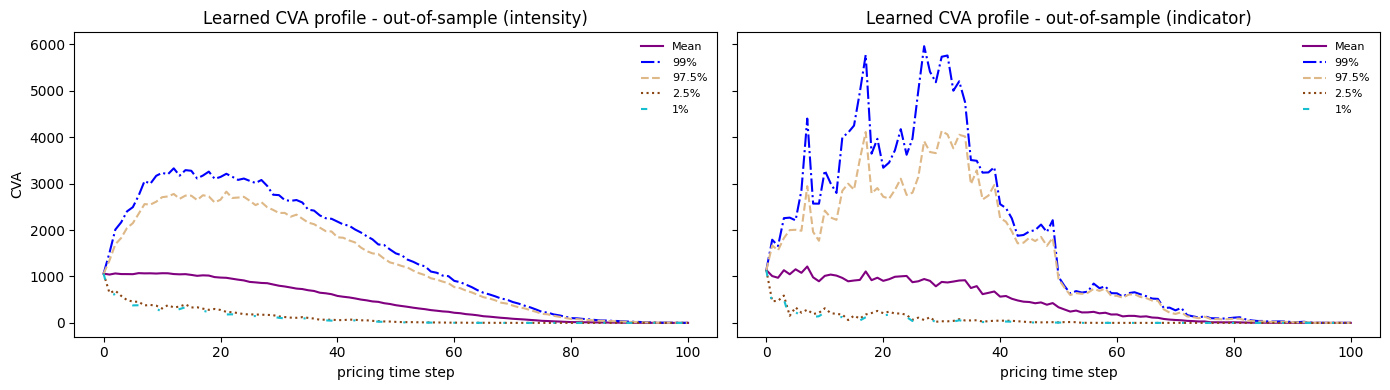

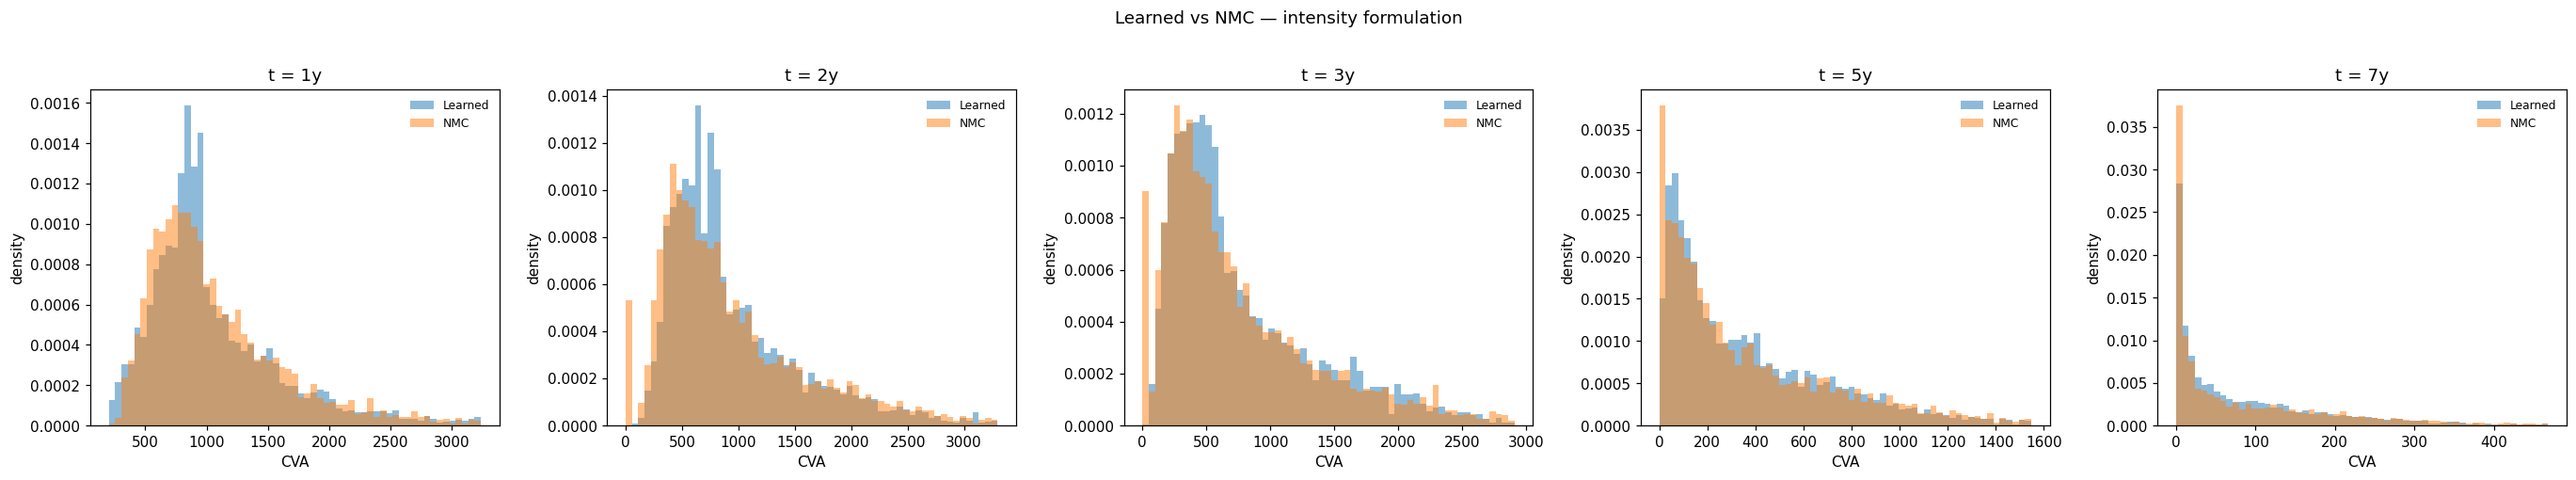

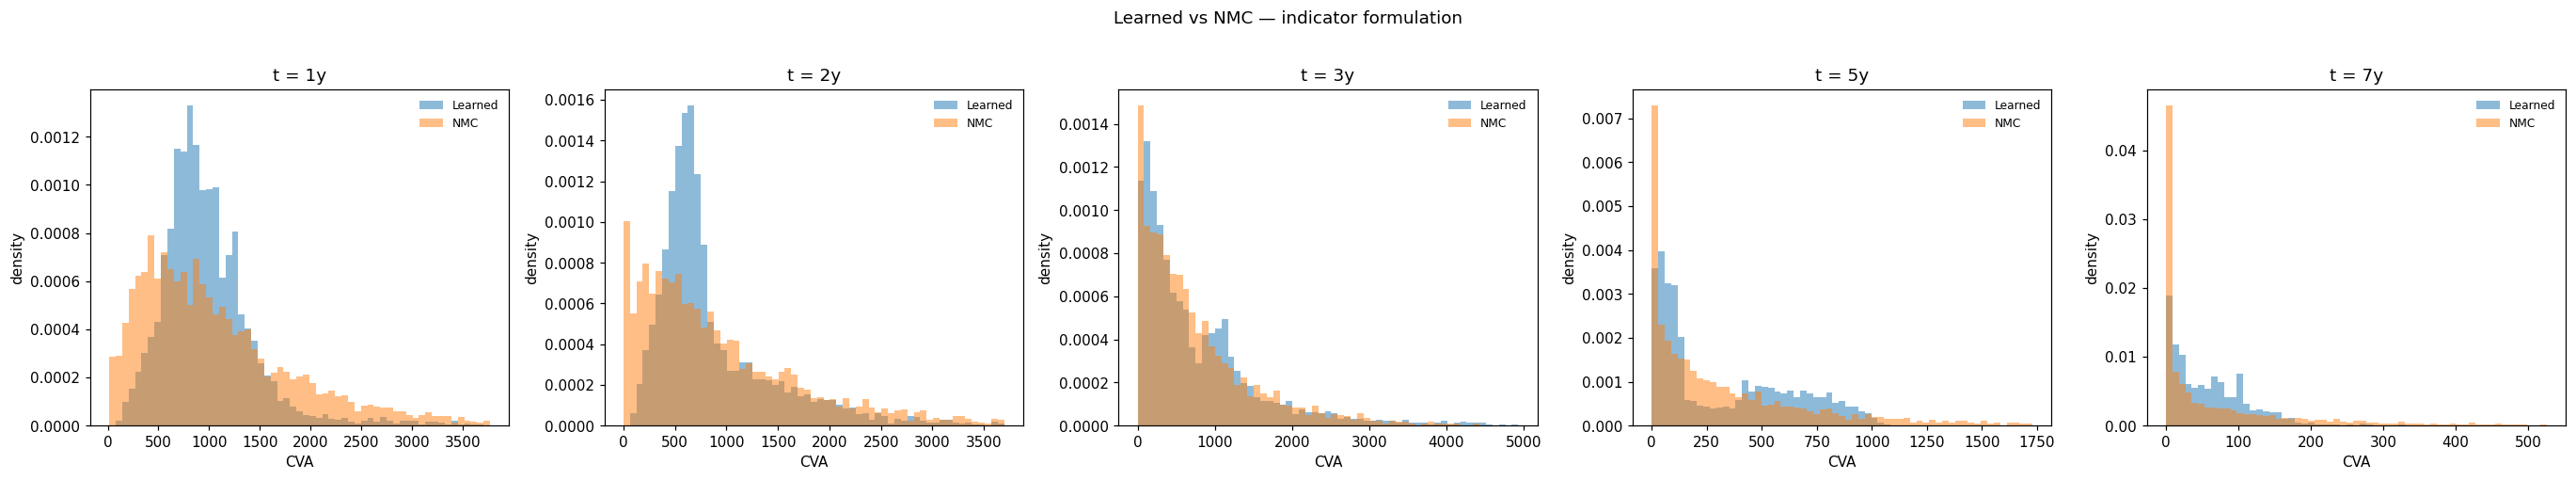

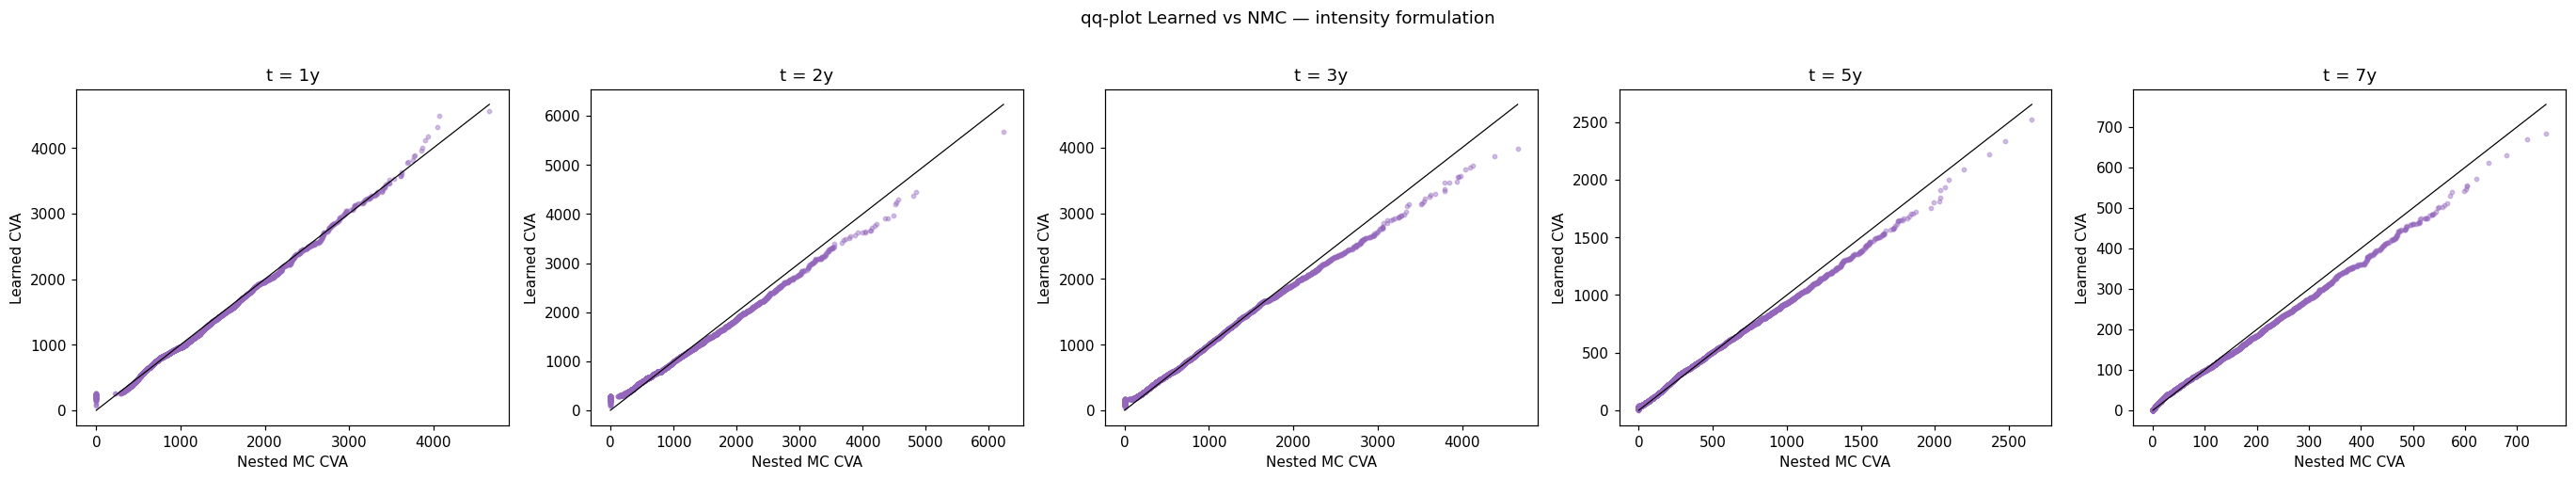

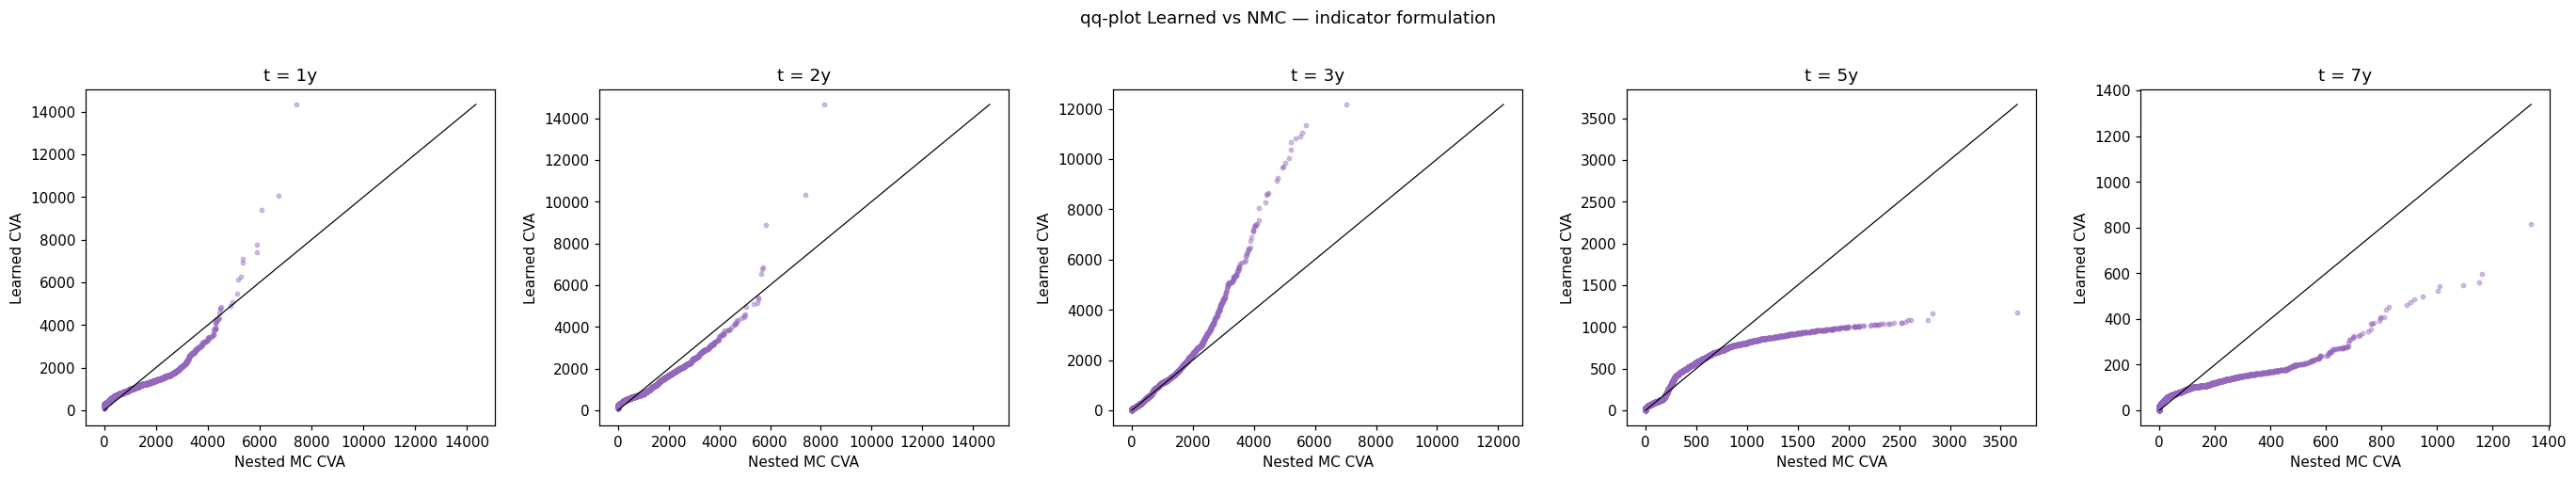

In [12]:
# out-of-sample paths to validate
num_outer_paths_oos = 4096
rng_oos = np.random.default_rng(123)
X_oos, default_step_oos, rate_integral_oos, gamma_integral_oos = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths_oos,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho,
    rng=rng_oos,
)

# out-of-sample features
features_by_t_oos = np.zeros(
    (num_steps_total + 1, num_outer_paths_oos, input_dim), dtype=np.float32
)
for step in range(num_steps_total + 1):
    idx = (fixing_window_size - 1) if step == 0 else (fixing_window_size + step - 1)
    features_by_t_oos[step, :, 0] = X_oos[idx, 0, :]
    features_by_t_oos[step, :, 1] = X_oos[idx, 1, :]

# validating both learners
cva_learned_oos_int = learner_int.predict(features_by_t_oos)
cva_learned_oos_ind = learner_ind.predict(features_by_t_oos)

# Running NMC as reference at selected dates
dates_years = [1.0, 2.0, 3.0, 5.0, 7.0]
dates_steps = [int(t / dT) for t in dates_years]
n_inner = 128  # assumed enough from previous notebook

nmc_int, nmc_ind = {}, {}
for t_step, t_year in zip(dates_steps, dates_years):
    print(f"\n Nested MC estimate at t={t_year}y (step {t_step}) ===")
    for indicator, store, name in [(False, nmc_int, 'intensity'), (True, nmc_ind, 'indicator')]:
        t0 = time.time()
        cva, _, _ = simulate_nested_cva(
            t_i_idx=t_step, n_inner=n_inner, indicator=indicator,
            X=X_oos, default_step=default_step_oos, irs=irs,
            diff_params=diff_params, rho=rho,
            dt=dt, num_substeps=num_substeps, num_steps_total=num_steps_total,
            num_outer_paths=num_outer_paths_oos, fixing_window_size=fixing_window_size,
            dT=dT, seed=123,
        )
        store[t_step] = cva
        print(f"  {name}: {time.time()-t0:.1f}s | mean={cva.mean():.2f}")

# out-of-sample CVA profile for both learners (inspo from the course)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100, sharey=True)
for ax, cva, title in [(axes[0], cva_learned_oos_int, 'intensity'), (axes[1], cva_learned_oos_ind, 'indicator')]:
    ax.plot(cva.mean(axis=1), label='Mean', color='purple')
    ax.plot(np.percentile(cva, 99, axis=1),   label='99%',   color='blue',        linestyle='dashdot')
    ax.plot(np.percentile(cva, 97.5, axis=1), label='97.5%', color='burlywood',   linestyle='dashed')
    ax.plot(np.percentile(cva, 2.5, axis=1),  label='2.5%',  color='saddlebrown', linestyle='dotted')
    ax.plot(np.percentile(cva, 1, axis=1),    label='1%',    color='tab:cyan',    linestyle=(0, (3, 10, 1, 10)))
    ax.set_xlabel('pricing time step')
    ax.set_title(f'Learned CVA profile - out-of-sample ({title})')
    ax.legend(loc='upper right', frameon=False, fontsize=8)
axes[0].set_ylabel('CVA')
plt.tight_layout()
plt.show()

# density plot (inspo from the course)
for cva_learned, nmc_dict, name in [
    (cva_learned_oos_int, nmc_int, 'intensity'),
    (cva_learned_oos_ind, nmc_ind, 'indicator'),
]:
    fig, axes = plt.subplots(1, len(dates_steps), figsize=(5 * len(dates_steps), 4.5), dpi=110)
    for ax, t_step, t_year in zip(axes, dates_steps, dates_years):
        learned = cva_learned[t_step]
        nmc = nmc_dict[t_step]
        all_vals = np.concatenate([learned, nmc])
        bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 60)
        ax.hist(learned, bins=bins, alpha=0.5, label='Learned', color='tab:blue',   density=True)
        ax.hist(nmc,     bins=bins, alpha=0.5, label='NMC',     color='tab:orange', density=True)
        ax.set_title(f"t = {t_year:.0f}y")
        ax.set_xlabel('CVA')
        ax.set_ylabel('density')
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(f'Learned vs NMC — {name} formulation', y=1.02)
    plt.tight_layout()
    plt.show()

# qq-plots
for cva_learned, nmc_dict, name in [
    (cva_learned_oos_int, nmc_int, 'intensity'),
    (cva_learned_oos_ind, nmc_ind, 'indicator'),
]:
    fig, axes = plt.subplots(1, len(dates_steps), figsize=(5 * len(dates_steps), 4.5), dpi=110)
    for ax, t_step, t_year in zip(axes, dates_steps, dates_years):
        learned = np.sort(cva_learned[t_step])
        nmc = np.sort(nmc_dict[t_step])
        lo, hi = min(nmc.min(), learned.min()), max(nmc.max(), learned.max())
        ax.plot([lo, hi], [lo, hi], color='black', lw=0.8)
        ax.scatter(nmc, learned, s=8, alpha=0.4, color='tab:purple')
        ax.set_xlabel('Nested MC CVA')
        ax.set_ylabel('Learned CVA')
        ax.set_title(f"t = {t_year:.0f}y")
    fig.suptitle(f'qq-plot Learned vs NMC — {name} formulation', y=1.02)
    plt.tight_layout()
    plt.show()

## References

<a id="achs"></a>
**[1]** C. Albanese, S. Crépey, R. Hoskinson, B. Saadeddine.
*XVA Analysis From the Balance Sheet.* Quantitative Finance, 21(1), 99–123, 2021.

<a id="acs"></a>
**[2]** L. A. Abbas-Turki, S. Crépey, B. Saadeddine.
*Pathwise CVA Regressions With Oversimulated Defaults.* Mathematical Finance, 2022.

<a id="acd"></a>
**[3]** L. A. Abbas-Turki, S. Crépey, B. Diallo.
*XVA Principles, Nested Monte Carlo Strategies, and GPU Optimizations.* International Journal of Theoretical and Applied Finance, 21(6), 1850030, 2018.

<a id="course"></a>
**[4]** J.F. Chassagneux.  
*Numerical Methods in Financial Engineering.* Course notes, 2026.

<a id="giles"></a>
**[5]** M. Giles.
*Advanced Monte Carlo Methods: American Options.* Lecture notes, Oxford University Mathematical Institute.

<a id="atg"></a>
**[6]** L. A. Abbas-Turki, S. Graillat.
*Resolution of a large number of small random symmetric linear systems in single precision arithmetic on GPUs.* Journal of Supercomputing, 73(4), 1360–1386, 2017.

<a id="ls"></a>
**[7]** F. A. Longstaff, E. S. Schwartz.
*Valuing American Options by Simulation: A Simple Least-Squares Approach.* Anderson Graduate School of Management, Finance, UCLA, 2001.

<a id="aaad"></a>
**[8]** B. Saadeddine. *NeuralXVA: simulation and neural-net learning of path-wise XVAs.* GitHub repository, 2020.

<a id="gpw"></a>
**[9]** M. Germain, H. Pham, X. Warin. *Approximation error analysis of some deep backward schemes for nonlinear PDEs.* SIAM Journal on Scientific Computing, 43(5), 2021.

<a id="acss"></a>
**[10]** L. Abbas-Turki, S. Crépey, B. Saadeddine, W. Sabbagh. *Pathwise XVAs: The Direct Scheme.* Preprint, 31 October 2022.

<a id="fg"></a>
**[11]** R. Ferguson, A. Green. *Deeply Learning Derivatives.* Preprint, version 2.1, 14 October 2018. arXiv:1809.02233.